Saving letter-recognition.csv to letter-recognition.csv
  letter  xbox   ybox   width   height  onpix   xbar   ybar   x2bar  y2bar   \
0      T      2      8       3       5       1      8     13      0       6   
1      I      5     12       3       7       2     10      5      5       4   
2      D      4     11       6       8       6     10      6      2       6   
3      N      7     11       6       6       3      5      9      4       6   
4      G      2      1       3       1       1      8      6      6       6   

   xybar   x2ybar  xy2bar  xedge   xedgey  yedge   yedgex  
0       6      10       8       0       8       0       8  
1      13       3       9       2       8       4      10  
2      10       3       7       3       7       3       9  
3       4       4      10       6      10       2       8  
4       6       5       9       1       7       5      10  
(20000, 17)
Index(['letter', 'xbox ', 'ybox ', 'width ', 'height', 'onpix ', 'xbar ',
       'ybar ', 'x2bar'

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5301 - loss: 1.6523 - val_accuracy: 0.7391 - val_loss: 0.9212
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7857 - loss: 0.7329 - val_accuracy: 0.8003 - val_loss: 0.6677
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8374 - loss: 0.5480 - val_accuracy: 0.8406 - val_loss: 0.5383
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8678 - loss: 0.4455 - val_accuracy: 0.8678 - val_loss: 0.4500
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8888 - loss: 0.3720 - val_accuracy: 0.8766 - val_loss: 0.4059
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9057 - loss: 0.3156 - val_accuracy: 0.8997 - val_loss: 0.3445
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9155 - loss: 0.2770 - val_accuracy: 0.8966 - val_loss: 0.3308
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9245 - loss: 0.2425 - val_accuracy: 0.9062 - val_

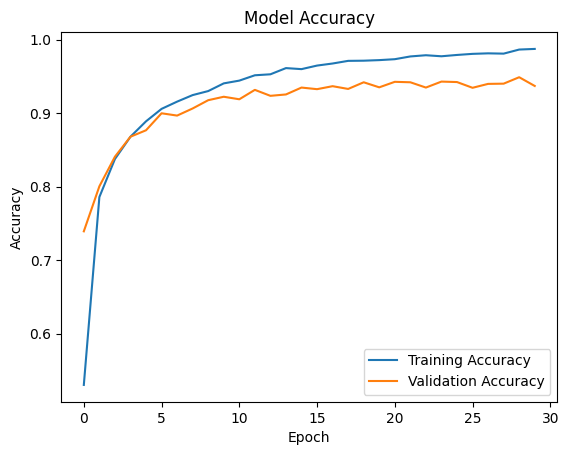

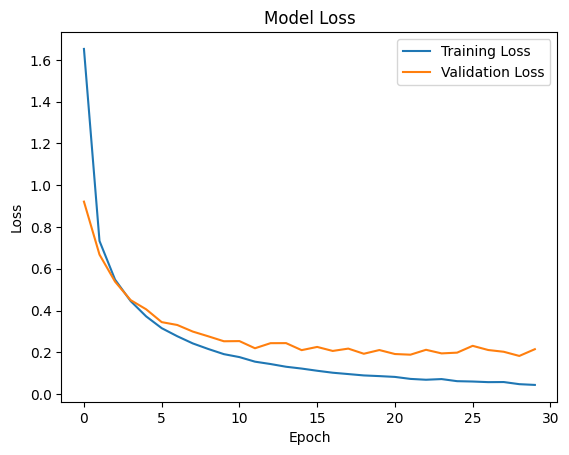

In [1]:
# ================================
# Multiclass Classification using Deep Neural Network
# OCR Letter Recognition Dataset
# Google Colab Complete Code
# ================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Step 2: Upload Dataset
from google.colab import files

uploaded = files.upload()

# Step 3: Load Dataset
# Replace filename with your uploaded Kaggle filename

df = pd.read_csv('letter-recognition.csv')

# Show first 5 rows
print(df.head())

# Step 4: Check Dataset Info
print(df.shape)
print(df.columns)

# Step 5: Handle Missing Values
print(df.isnull().sum())

df = df.dropna()

# Step 6: Separate Features and Target
# First column = target letter

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

# Step 7: Encode Target Labels
# Convert A-Z into numbers 0-25

encoder = LabelEncoder()

y = encoder.fit_transform(y)

# Convert into One Hot Encoding
y = to_categorical(y)

# Step 8: Feature Scaling
scaler = StandardScaler()

X = scaler.fit_transform(X)

# Step 9: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 10: Build Deep Neural Network

model = Sequential()

# Input + Hidden Layers
model.add(Dense(128, activation='relu', input_shape=(16,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output Layer (26 classes)
model.add(Dense(26, activation='softmax'))

# Step 11: Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step 12: Train Model

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

# Step 13: Evaluate Model

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

# Step 14: Predict Sample

prediction = model.predict(X_test)

predicted_class = np.argmax(prediction[0])
actual_class = np.argmax(y_test[0])

print("\nPredicted Letter:",
      encoder.inverse_transform([predicted_class])[0])

print("Actual Letter:",
      encoder.inverse_transform([actual_class])[0])

# Step 15: Accuracy Graph

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

# Step 16: Loss Graph

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()